Para la lectura de datos, MATLAB utiliza el tipo de dato table. Es importante notar la sintaxis de indexación datostabla{:,3}:

Las llaves {} extraen el contenido crudo de la celda.

El : selecciona todas las filas.

Se utiliza la librería externa m_map con una proyección Lambert Conforme para minimizar la distorsión en latitudes medias.

datostabla = readtable('glacier_inventory_region_extract.csv');

% Extracción de datos {Fila , Columna}
lat = datostabla{:,3}; 
lon = datostabla{:,4};

figure; 

% Configuración de Proyección Lambert y límites geográficos
m_proj('lambert', 'lon', [min(lon)-1 max(lon)+1], 'lat', [min(lat)-1 max(lat)+1]);
hold on

m_coast('patch', [0.7 0.7 0.7]);       % Costa en color gris
m_grid('box', 'fancy', 'tickdir', 'in'); % Marco con estilo

% Ploteo: 'bo' = blue circles
m_plot(lon, lat, 'bo', 'MarkerFaceColor', 'cyan');

title('Distribución de Glaciares en la Región');

Se encontraron 734 glaciares con coordenadas válidas.


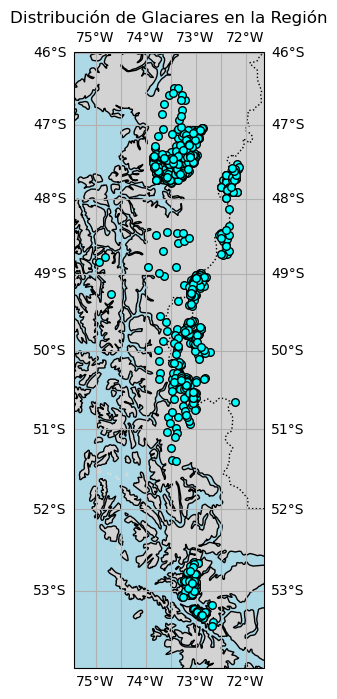

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Cargar el archivo (Formato estándar)
# skipinitialspace=True ayuda si hay espacios después de la coma
df = pd.read_csv('glacier_inventory_region_extract.csv', skipinitialspace=True)

# 2. Limpieza 
# Solo borramos la fila si falta 'lat' o 'lon'.
# Si falta el nombre (glacier_name), la fila SE QUEDA.
df = df.dropna(subset=['lat', 'lon'])

print(f"Se encontraron {len(df)} glaciares con coordenadas válidas.")

# 3. Extraer datos
lat = df['lat'].values
lon = df['lon'].values

# 4. Graficar
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.Mercator())

# Ajustar vista automáticamente a los datos con un margen
margin = 0.5
ax.set_extent([min(lon)-margin, max(lon)+margin, min(lat)-margin, max(lat)+margin], crs=ccrs.PlateCarree())

# Características del mapa
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Puntos
ax.scatter(lon, lat, color='cyan', edgecolors='black', s=30, transform=ccrs.PlateCarree(), zorder=5)

plt.title('Distribución de Glaciares en la Región')
plt.show()

Resumir y explicar las diferencias del código en Python a diferencia del código en Matlab